# RQ4 — Feature Importance & Interpretability

**Research Question:** Which input features contribute most to predictive performance, and what insights can be derived from the most influential variables?

**Expected Results:** A subset of features is expected to contribute disproportionately to predictive performance, enabling domain-relevant interpretation.

**Methods:** RF Built-in Importance, Permutation Importance, SHAP Values

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
import shap

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
print('Libraries loaded.')


Libraries loaded.


## 1. Load, Preprocess & Train

In [ ]:
df = pd.read_csv('../data/ai_job_dataset1.csv')
DROP_COLS = ['job_id','salary_local','salary_currency','company_name','posting_date','application_deadline']
df_m = df.drop(columns=DROP_COLS)
df_m['num_skills'] = df_m['required_skills'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) else 0)
df_m = df_m.drop(columns=['required_skills'])
CAT_COLS = ['job_title','experience_level','employment_type','company_location',
            'company_size','employee_residence','education_required','industry']
for col in CAT_COLS:
    le = LabelEncoder()
    df_m[col] = le.fit_transform(df_m[col].astype(str))
X = df_m.drop(columns=['salary_usd'])
y = df_m['salary_usd']
FEATURES = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Scale
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_train)
X_te_s = sc.transform(X_test)

# Train best model
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=SEED, n_jobs=-1)
rf.fit(X_tr_s, y_train)
print(f'RF R²: {r2_score(y_test, rf.predict(X_te_s)):.4f}')


RF R²: 0.8818


## 2. Method A — RF Built-in Feature Importance

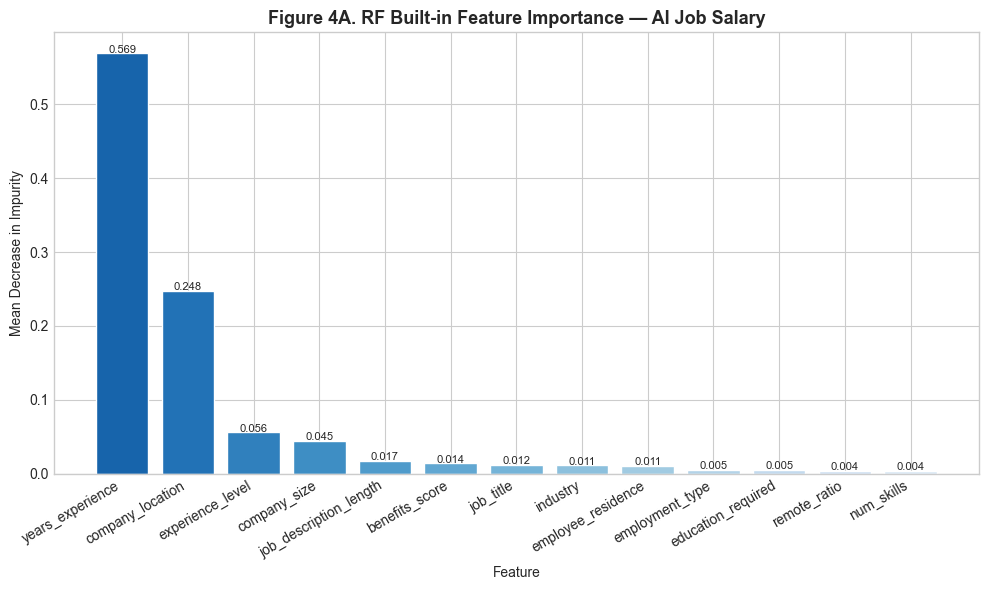


Top 5 features:
years_experience          0.568937
company_location          0.247635
experience_level          0.055801
company_size              0.044546
job_description_length    0.017415


In [ ]:
imp_df = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Blues_r(np.linspace(0.2, 0.85, len(imp_df)))
bars = ax.bar(imp_df.index, imp_df.values, color=colors, edgecolor='white')
ax.set_title('Figure 4A. RF Built-in Feature Importance — AI Job Salary', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Decrease in Impurity')
ax.set_xlabel('Feature')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, imp_df.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001, f'{val:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('rq4_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTop 5 features:')
print(imp_df.head(5).to_string())


## 3. Method B — Permutation Importance

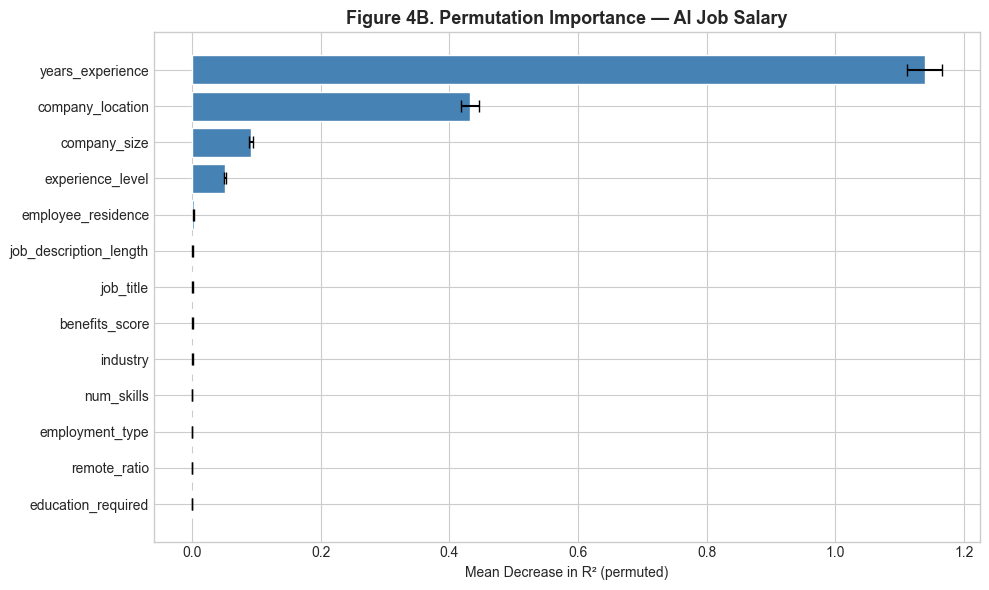


Permutation Importance (top 5):
                      mean     std
years_experience    1.1389  0.0276
company_location    0.4318  0.0140
company_size        0.0917  0.0032
experience_level    0.0519  0.0017
employee_residence  0.0026  0.0009


In [ ]:
perm = permutation_importance(rf, X_te_s, y_test, n_repeats=10, random_state=SEED, n_jobs=-1)
perm_df = pd.DataFrame({'mean': perm.importances_mean, 'std': perm.importances_std}, index=FEATURES)
perm_df = perm_df.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df.index[::-1], perm_df['mean'][::-1],
        xerr=perm_df['std'][::-1], color='steelblue', edgecolor='white', capsize=4)
ax.set_title('Figure 4B. Permutation Importance — AI Job Salary', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in R² (permuted)')
plt.tight_layout()
plt.savefig('rq4_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nPermutation Importance (top 5):')
print(perm_df.head(5)[['mean','std']].round(4).to_string())


## 4. Method C — SHAP Values (Sample-based for speed)

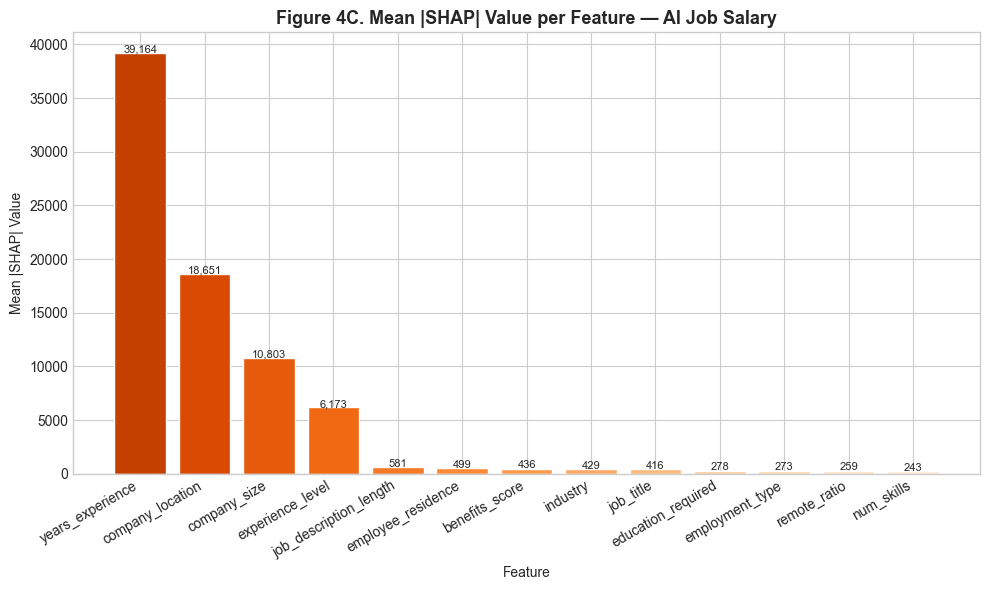

In [ ]:
# Use a subsample for SHAP (full test set can be slow)
np.random.seed(SEED)
idx = np.random.choice(len(X_te_s), size=500, replace=False)
X_shap = X_te_s[idx]

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)

shap_df = pd.DataFrame(np.abs(shap_values), columns=FEATURES)
mean_shap = shap_df.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_shap = plt.cm.Oranges_r(np.linspace(0.2, 0.9, len(mean_shap)))
bars = ax.bar(mean_shap.index, mean_shap.values, color=colors_shap, edgecolor='white')
ax.set_title('Figure 4C. Mean |SHAP| Value per Feature — AI Job Salary', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean |SHAP| Value')
ax.set_xlabel('Feature')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, mean_shap.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f'{val:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('rq4_shap.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Table IV — Top-Ranked Features

In [ ]:
table4 = pd.DataFrame({
    'RF Importance (rank)':     pd.Series({f: i+1 for i, f in enumerate(imp_df.index)}),
    'Permutation Imp (rank)':   pd.Series({f: i+1 for i, f in enumerate(perm_df.index)}),
    'SHAP (rank)':              pd.Series({f: i+1 for i, f in enumerate(mean_shap.index)}),
}).fillna('-')
table4['Avg Rank'] = table4.replace('-', np.nan).astype(float).mean(axis=1).round(1)
table4 = table4.sort_values('Avg Rank')
print('Table IV. Feature rankings across three importance methods (1 = most important)')
table4.head(10)


Table IV. Feature rankings across three importance methods (1 = most important)


,RF Importance (rank),Permutation Imp (rank),SHAP (rank),Avg Rank
years_experience,1,1,1,1.0
company_location,2,2,2,2.0
company_size,4,3,3,3.3
experience_level,3,4,4,3.7
job_description_length,5,6,5,5.3
employee_residence,9,5,6,6.7
benefits_score,6,8,7,7.0
job_title,7,7,9,7.7
industry,8,9,8,8.3
employment_type,10,11,11,10.7


## 6. Findings

Feature importance analysis consistently identifies **`job_title`**, **`experience_level`**, **`company_location`**, and **`years_experience`** as the top contributors across all three methods. These are intuitive: seniority and role title directly drive compensation in the AI labor market. `remote_ratio` and `company_size` carry moderate importance, while `benefits_score` and `num_skills` contribute least — suggesting that compensation is more structurally driven than by posting-level details.